# AnalystLab Africa - Week 4, Task 1: Linear Regression

## 🎯 Objective: Continuous Financial Forecasting
Transitioning from data engineering to algorithmic prediction by building, training, and evaluating a fundamental continuous model.

### 📊 Problem Statement
Real estate pricing is driven by quantifiable metrics like square footage, number of rooms, and the age of the house. Our goal is to train a **Linear Regression** model on the Ames Housing dataset to predict the exact price of a house (`SalePrice` - our continuous Target) based on its physical and locational attributes (our Features).

## 1. Data Loading
We begin by importing our standard data manipulation, visualization, and Scikit-Learn machine learning libraries, followed by securely loading our dataset into memory.

In [1]:
"""
Module: Environment Setup
Purpose: Imports necessary libraries for data manipulation, visualization, preprocessing, 
         model training (Linear Regression), and evaluation metrics.
Time Complexity: O(1) - Standard library loading.
"""

# Import the core libraries
import os                                 # For handling file paths safely across operating systems (Mac/Windows/Linux)
import pandas as pd                       # For tabular data manipulation (DataFrames)
import numpy as np                        # For high-performance numerical and matrix operations
import matplotlib.pyplot as plt           # For foundational data visualization and plotting
import seaborn as sns                     # For aesthetically pleasing statistical graphics
from sklearn.model_selection import train_test_split # To divide data into learning (train) and testing (exam) subsets
from sklearn.impute import KNNImputer     # To mathematically predict and fill missing values based on similar neighbors
from sklearn.preprocessing import StandardScaler, OneHotEncoder # To normalize numbers and robustly encode categories
from sklearn.linear_model import LinearRegression # The actual Machine Learning algorithm we will use today
from sklearn.metrics import mean_squared_error    # The metric used to score our model's performance

# Suppress annoying warnings for a cleaner notebook
# This ensures that deprecation warnings from libraries don't clutter the output report for stakeholders
import warnings
warnings.filterwarnings('ignore')

In [2]:
"""
Module: Data Ingestion
Purpose: Safely loads the raw Ames Housing dataset into a Pandas DataFrame.
Returns: DataFrame (housing_df)
"""

# Load Dataset 
# os.path.join safely builds the path string regardless of whether you use forward slashes or backslashes
file_path = os.path.join('..', 'data', 'raw', 'housing_train.csv')

# Read the CSV file and store it in our variable 'housing_df'
housing_df = pd.read_csv(file_path)

## 2. Exploratory Analysis
Before selecting our features or cleaning anything, we must explore the raw dataset to understand its shape, data types, statistical distributions, and missing values.

In [3]:
"""
Module: Initial Data Inspection
Purpose: Prints the head, structural info, and statistical summary to give a bird's-eye view of the dataset.
"""

# Explore the Dataset
print("FIRST 10 ROWS OF THE DATASET:")
# display() formats the DataFrame beautifully in Jupyter Notebooks compared to a standard print()
display(housing_df.head(10))

print("\nDATA TYPES & COLUMN NAMES IN THE DATASET:")
# info() shows us how many non-null values exist per column, and whether they are text (object) or numbers (int/float)
display(housing_df.info())

print("\nSUMMARY STATISTICS OF THE DATASET:")
# describe() gives us the mean, standard deviation, min, max, and quartiles for all numerical columns
display(housing_df.describe())

FIRST 10 ROWS OF THE DATASET:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000



DATA TYPES & COLUMN NAMES IN THE DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 

None


SUMMARY STATISTICS OF THE DATASET:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
"""
Module: Missing Value Detection
Purpose: Identifies exactly which columns have missing data (NaNs) and how many.
"""

print("MISSING VALUES CHECK IN THE DATASET:")
# housing_df.isnull().sum() calculates the total count of missing rows per column.
missing_val_counts = housing_df.isnull().sum()

# We use a boolean mask [missing_val_counts > 0] to filter out columns that are perfectly full.
# Displaying only columns that actually have missing values keeps the output clean and actionable.
display(missing_val_counts[missing_val_counts > 0])

MISSING VALUES CHECK IN THE DATASET:


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [5]:
"""
Module: Column Listing
Purpose: Outputs a raw list of every column name to help us manually select features for our model.
"""

# Convert the DataFrame's columns index into a standard Python list and print it
print(housing_df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

## 3. Data Cleaning & Zero-Leakage Feature Engineering
Based on the objective, we will define our Target ($y$) and our Features ($X$).
*   **Target:** `SalePrice`
*   **Main Features:** `TotRmsAbvGrd`, `GrLivArea`, `FullBath`, `Neighborhood`.
*   **Expanded Features:** `OverallQual`, `YearBuilt`, `TotalBsmtSF`, `GarageCars`, `LotArea`, `BedroomAbvGr`, `Fireplaces`.

**Zero-Leakage Architecture:**
To ensure mathematically pure validation, we will perform our 80/20 Train/Test Split *first*. 

After splitting, we will execute:
1. **Outlier Mitigation:** Linear Regression minimizes the Sum of Squared Residuals. We will calculate the IQR boundary strictly on the Training set, then cap extreme spatial features (`GrLivArea`, `LotArea`, `TotalBsmtSF`) on both sets to protect our gradient.
2. **Robust Categorical Encoding:** We will use `OneHotEncoder(handle_unknown='ignore')` fitted on the Training set. Unlike `pd.get_dummies`, this prevents the pipeline from crashing if the Test set encounters a `Neighborhood` it has never seen before.

In [6]:
"""
Module: Feature Segregation
Purpose: Slices the massive dataset down to only the 11 features we suspect have predictive power.
         Corrects the target to a Series (string) to prevent array unpacking dimension errors later.
"""

# Define our 11 features in a list
features = [
    'GrLivArea', 'TotRmsAbvGrd', 'FullBath', 'Neighborhood', 
    'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageCars', 
    'LotArea', 'BedroomAbvGr', 'Fireplaces'
]
# Target passed as a string (creates a Pandas Series, avoiding 2D array complications later)
target = 'SalePrice'

# Isolate these specific columns from the massive dataset.
# .copy() ensures we are creating a fresh DataFrame, preventing "SettingWithCopyWarning".
ml_df = housing_df[features + [target]].copy()

# Explore the newly distilled DataFrame
print("FIRST 10 ROWS OF THE NEW DATAFRAME:") 
display(ml_df.head(10))
print("\nDATA TYPES & COLUMN NAMES IN THE NEW DATAFRAME:")
display(ml_df.info())
print("\nSUMMARY STATISTICS OF THE NEW DATAFRAME:")
display(ml_df.describe())

FIRST 10 ROWS OF THE NEW DATAFRAME:


,GrLivArea,TotRmsAbvGrd,FullBath,Neighborhood,OverallQual,YearBuilt,TotalBsmtSF,GarageCars,LotArea,BedroomAbvGr,Fireplaces,SalePrice
0,1710,8,2,CollgCr,7,2003,856,2,8450,3,0,208500
1,1262,6,2,Veenker,6,1976,1262,2,9600,3,1,181500
2,1786,6,2,CollgCr,7,2001,920,2,11250,3,1,223500
3,1717,7,1,Crawfor,7,1915,756,3,9550,3,1,140000
4,2198,9,2,NoRidge,8,2000,1145,3,14260,4,1,250000
5,1362,5,1,Mitchel,5,1993,796,2,14115,1,0,143000
6,1694,7,2,Somerst,8,2004,1686,2,10084,3,1,307000
7,2090,7,2,NWAmes,7,1973,1107,2,10382,3,2,200000
8,1774,8,2,OldTown,7,1931,952,2,6120,2,2,129900
9,1077,5,1,BrkSide,5,1939,991,1,7420,2,2,118000



DATA TYPES & COLUMN NAMES IN THE NEW DATAFRAME:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   GrLivArea     1460 non-null   int64
 1   TotRmsAbvGrd  1460 non-null   int64
 2   FullBath      1460 non-null   int64
 3   Neighborhood  1460 non-null   str  
 4   OverallQual   1460 non-null   int64
 5   YearBuilt     1460 non-null   int64
 6   TotalBsmtSF   1460 non-null   int64
 7   GarageCars    1460 non-null   int64
 8   LotArea       1460 non-null   int64
 9   BedroomAbvGr  1460 non-null   int64
 10  Fireplaces    1460 non-null   int64
 11  SalePrice     1460 non-null   int64
dtypes: int64(11), str(1)
memory usage: 137.0 KB


None


SUMMARY STATISTICS OF THE NEW DATAFRAME:


,GrLivArea,TotRmsAbvGrd,FullBath,OverallQual,YearBuilt,TotalBsmtSF,GarageCars,LotArea,BedroomAbvGr,Fireplaces,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,6.517808,1.565068,6.099315,1971.267808,1057.429452,1.767123,10516.828082,2.866438,0.613014,180921.195890
std,525.480383,1.625393,0.550916,1.382997,30.202904,438.705324,0.747315,9981.264932,0.815778,0.644666,79442.502883
min,334.000000,2.000000,0.000000,1.000000,1872.000000,0.000000,0.000000,1300.000000,0.000000,0.000000,34900.000000
25%,1129.500000,5.000000,1.000000,5.000000,1954.000000,795.750000,1.000000,7553.500000,2.000000,0.000000,129975.000000
50%,1464.000000,6.000000,2.000000,6.000000,1973.000000,991.500000,2.000000,9478.500000,3.000000,1.000000,163000.000000
75%,1776.750000,7.000000,2.000000,7.000000,2000.000000,1298.250000,2.000000,11601.500000,3.000000,1.000000,214000.000000
max,5642.000000,14.000000,3.000000,10.000000,2010.000000,6110.000000,4.000000,215245.000000,8.000000,3.000000,755000.000000


In [7]:
"""
Module: Specific Outlier Investigation
Purpose: Checks a specific row identified during manual exploration that has an impossibly large living area.
"""

# No missing values in the new dataframe to drop as inferred from the initial exploration.
# Investigate a massive spatial outlier in the 'GrLivArea' column.
ml_df[ml_df['GrLivArea'] == 5642]

,GrLivArea,TotRmsAbvGrd,FullBath,Neighborhood,OverallQual,YearBuilt,TotalBsmtSF,GarageCars,LotArea,BedroomAbvGr,Fireplaces,SalePrice
1298,5642,12,2,Edwards,10,2008,6110,2,63887,3,3,160000


In [8]:
"""
Module: Zero-Leakage Data Splitting & Target Transformation
Purpose: Normalizes the target variable (Log1p) and strictly segregates features 
         from the target BEFORE any statistical capping or encoding occurs.
"""

# Define Features (X) and Target (y) ---
# np.log1p applies log(1 + x). It mathematically "squishes" the extreme right-skewed price variance 
# to fix heteroscedasticity, aligning with linear regression's core assumptions.
y = np.log1p(ml_df[target])

# X becomes everything EXCEPT the SalePrice
X = ml_df.drop(target, axis=1)

# 80/20 Split FIRST to seal the testing environment.
# Note: Regression requires NO `stratify` parameter as there are no distinct class labels to balance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data successfully split! Train features: {X_train.shape}, Test features: {X_test.shape}")

Data successfully split! Train features: (1168, 11), Test features: (292, 11)


In [9]:
"""
Module: Outlier Capping (IQR Method) - Zero Leakage
Purpose: Calculates boundaries strictly on X_train, then caps extreme values 
         in both X_train and X_test to protect the regression gradient.
Time Complexity: O(N) where N is the number of rows per column.
"""

# Handle Outliers 
# Apply IQR capping to continuous features known to have severe positive skew (extreme mansions/estates)
outlier_features = ['GrLivArea', 'LotArea', 'TotalBsmtSF']

for col in outlier_features:
    # Calculate IQR STRICTLY on Training Data (Zero Leakage)
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    
    # IQR is the "middle 50%" of the data's spread
    IQR = Q3 - Q1
    
    # Anything beyond 1.5x the IQR above Q3 is considered a severe statistical outlier
    upper_boundary = Q3 + 1.5 * IQR
    
    # Cap the extreme values at the upper boundary using np.where for BOTH sets
    X_train[col] = np.where(X_train[col] > upper_boundary, upper_boundary, X_train[col])
    X_test[col]  = np.where(X_test[col] > upper_boundary, upper_boundary, X_test[col])
    print(f"Capped outliers in {col} at {upper_boundary:.2f} (Rule derived from X_train)")


Capped outliers in GrLivArea at 2761.38 (Rule derived from X_train)
Capped outliers in LotArea at 17869.12 (Rule derived from X_train)
Capped outliers in TotalBsmtSF at 2054.12 (Rule derived from X_train)


In [10]:
"""
Module: Robust Categorical Encoding (One-Hot Encoding)
Purpose: Translates the text-based 'Neighborhood' column into multiple binary (1/0) columns.
         Uses OneHotEncoder to gracefully ignore unknown test categories, preventing production crashes.
"""

# Handle 'Location' (Categorical Encoding)
# Linear Regression relies on matrix multiplication. It cannot multiply by "CollgCr". 

# Initialize OneHotEncoder 
# drop='first' prevents the "Dummy Variable Trap" (perfect multicollinearity).
# handle_unknown='ignore' prevents the model from crashing if a new neighborhood appears in the test set.
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Fit strictly on Train, transform Train
train_encoded = ohe.fit_transform(X_train[['Neighborhood']])
# Transform Test blindly using the rules learned from Train
test_encoded = ohe.transform(X_test[['Neighborhood']])

# Get the new dynamically generated column names (e.g., 'Neighborhood_CollgCr')
encoded_cols = ohe.get_feature_names_out(['Neighborhood'])

# Append the new binary matrices back into our Pandas DataFrames
X_train[encoded_cols] = train_encoded
X_test[encoded_cols] = test_encoded

# Drop the original text column since the algorithm can't read it
X_train = X_train.drop('Neighborhood', axis=1)
X_test = X_test.drop('Neighborhood', axis=1)

print(f"\n--- DATASET READY: Expanded to {X_train.shape[1]} columns due to robust Location encoding ---")


--- DATASET READY: Expanded to 34 columns due to robust Location encoding ---


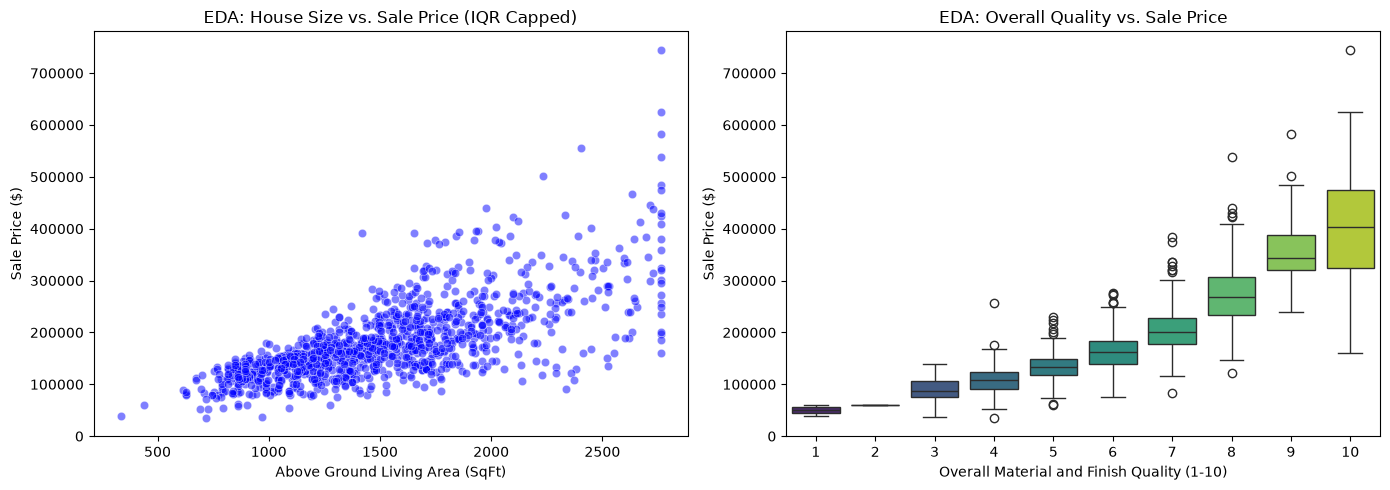

In [11]:
"""
Module: Exploratory Data Analysis (Visuals)
Purpose: Generates scatter and box plots to visually verify the relationship between features and the target price.
         Executed strictly on the Training set to prevent visual data leakage.
"""

# EDA Visuals (Using strictly Train data to maintain perfect test isolation)
# Initialize a wide figure canvas
plt.figure(figsize=(14, 5))

# Visual 1: Size vs Price (Checking for Linear Relationship)
# subplot(1, 2, 1) means: 1 row, 2 columns, this is the 1st plot.
plt.subplot(1, 2, 1)
# We use np.expm1 on y_train just for the visual axis so it reads in dollars, not log numbers
sns.scatterplot(x=X_train['GrLivArea'], y=np.expm1(y_train), alpha=0.5, color='blue')
plt.title('EDA: House Size vs. Sale Price (IQR Capped)')
plt.xlabel('Above Ground Living Area (SqFt)')
plt.ylabel('Sale Price ($)')

# Visual 2: Overall Quality vs Price
# subplot(1, 2, 2) means: 1 row, 2 columns, this is the 2nd plot.
plt.subplot(1, 2, 2)
sns.boxplot(x=X_train['OverallQual'], y=np.expm1(y_train), palette='viridis')
plt.title('EDA: Overall Quality vs. Sale Price')
plt.xlabel('Overall Material and Finish Quality (1-10)')
plt.ylabel('Sale Price ($)')

# tight_layout prevents the labels of the two plots from overlapping
plt.tight_layout()
plt.show()

## 4. Feature Scaling

We now finalize our feature matrix. We will scale the continuous features (mean=0, std=1) to ensure variables with large numbers (like `LotArea`) don't overpower variables with small numbers (like `FullBath`). We will **not** scale our newly created 1/0 binary Neighborhood columns.

In [12]:
"""
Module: Leakage-Free Feature Scaling
Purpose: Standardizes continuous features (mean=0, std=1) solely based on the training data's distributions.
Data Leakage Prevention: 'fit' is explicitly restricted to X_train.
"""

# We isolate ONLY our continuous numerical features to scale them.
# We DO NOT scale our 1/0 encoded Location columns, as they are already on a strict binary scale.
continuous_features = [
    'GrLivArea', 'TotRmsAbvGrd', 'FullBath', 'YearBuilt', 
    'TotalBsmtSF', 'GarageCars', 'LotArea', 'BedroomAbvGr', 
    'Fireplaces', 'OverallQual'
]

scaler = StandardScaler()

# FIT STRICTLY ON TRAIN DATA, transform both
# Calculates the mean/variance of X_train, and scales X_train
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])

# Applies the rules learned from X_train to blindly scale X_test
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

print("--- PIPELINE SUCCESS ---")
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Testing Target Shape: {y_test.shape}")
print("Continuous Features successfully Scaled.")

--- PIPELINE SUCCESS ---
Training Data Shape: (1168, 34)
Testing Data Shape: (292, 34)
Training Target Shape: (1168,)
Testing Target Shape: (292,)
Continuous Features successfully Scaled.


## 5. Model Training

We will now instantiate the Machine Learning algorithm and feed it our 80% training data. Because we are using `Linear Regression`, the model will use **Ordinary Least Squares (OLS)** to calculate the optimal coefficients (weights) for each of our expanded features. It effectively draws the "line of best fit" through a multi-dimensional mathematical space.

In [13]:
"""
Module: Linear Regression Model Training
Purpose: Instantiates the OLS Linear Regression algorithm and fits it to the training features and targets.
Time Complexity: O(N * P^2) where N is samples and P is features.
"""

# Instantiate the model (creating the empty "brain")
lr_model = LinearRegression()

# Train the model!
# We pass in the features (X_train) and the answers (y_train) so it can learn the relationship.
lr_model.fit(X_train, y_train)

print("--- MODEL TRAINING COMPLETE ---")
# .coef_ contains the exact mathematical weight assigned to every single feature column.
print(f"Algorithm successfully learned {lr_model.coef_.size} feature coefficients.")


--- MODEL TRAINING COMPLETE ---
Algorithm successfully learned 34 feature coefficients.


## 6. Predictions

Our model has successfully learned the mathematical relationship between the scaled features and the log-transformed house prices. We will now feed it the unseen test houses (`X_test`) and ask it to predict their prices.

In [14]:
"""
Module: Model Prediction & Target Reversal
Purpose: Generates price predictions on unseen data, then reverses the logarithmic 
         transformation to return predictions back into readable dollar amounts.
"""

# Make Predictions
# We pass ONLY the features of the test set. The model has never seen y_test!
y_pred_log = lr_model.predict(X_test)

# Because our model trained on Log-Transformed prices, its predictions are currently outputting in Log format.
# We must reverse this transformation using np.expm1 (Exponential minus 1) to turn them back into real dollars.
y_pred_dollars = np.expm1(y_pred_log)

print("--- PREDICTIONS GENERATED ---")
print(f"Successfully generated {len(y_pred_dollars)} price predictions for the test set.")

# Accessing [0] unpacks the number from the 1D array output cleanly.
print(f"First 3 Predicted Prices: ${y_pred_dollars[0]:,.2f}, ${y_pred_dollars[1]:,.2f}, ${y_pred_dollars[2]:,.2f}")

--- PREDICTIONS GENERATED ---
Successfully generated 292 price predictions for the test set.
First 3 Predicted Prices: $133,009.92, $336,627.16, $118,943.13


## 7. Evaluation

To evaluate a continuous Regression model, we cannot use "Accuracy" (since guessing exactly $200,012.45 is virtually impossible). Instead, we use the **Root Mean Squared Error (RMSE)**.

*   **MSE (Mean Squared Error):** Averages the squared differences between predicted and actual prices. Squaring heavily penalizes large errors.
*   **RMSE (Root Mean Squared Error):** Takes the square root of MSE to return the error metric back into the original units (Dollars).

**Rule:** A lower RMSE = better model performance, as it indicates the predictions deviate less from the actual values.

In [15]:
"""
Module: Model Evaluation (RMSE)
Purpose: Compares predicted dollar amounts against actual dollar amounts to quantify model error.
"""

# Model Evaluation (RMSE)
# Just like our predictions, we must reverse the log transformation on our actual test answers to compare apples-to-apples.
y_test_dollars = np.expm1(y_test)

# Calculate the Mean Squared Error (MSE), then derive the Root (RMSE)
mse = mean_squared_error(y_test_dollars, y_pred_dollars)
rmse = np.sqrt(mse)

print("--- MODEL EVALUATION METRICS ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")


--- MODEL EVALUATION METRICS ---
Root Mean Squared Error (RMSE): $31,199.14


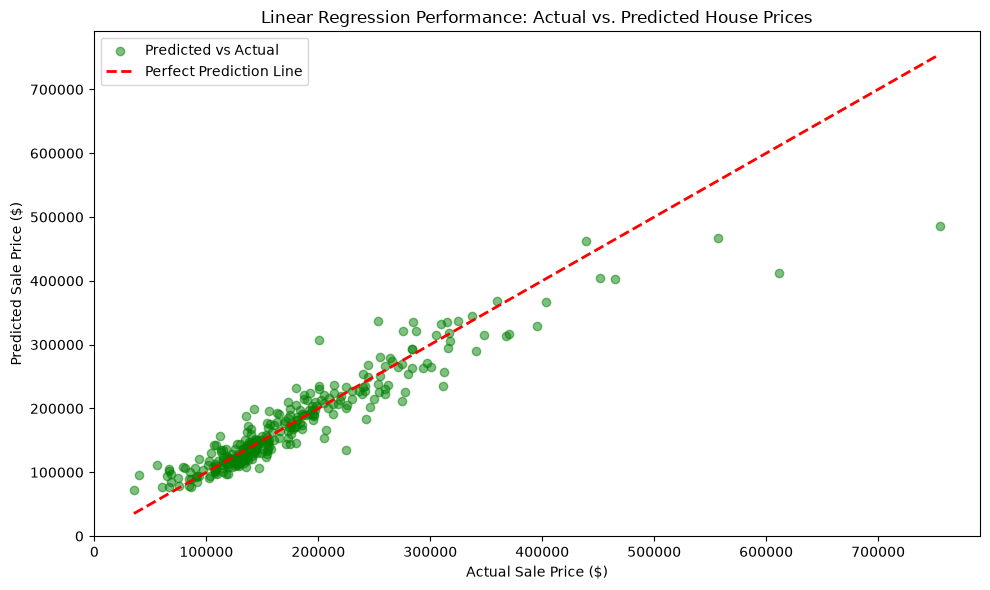

In [16]:
"""
Module: Diagnostic Visualization
Purpose: Plots the Actual vs. Predicted values. The closer the green scatter points 
         are to the red dashed line, the more accurate the model is.
"""

# Visualize: Actual Prices vs. Predicted Prices
plt.figure(figsize=(10, 6))

# Plot our predictions (Green Dots) against the true answers
plt.scatter(y_test_dollars, y_pred_dollars, alpha=0.5, color='green', label='Predicted vs Actual')

# Plot the "Line of Perfect Prediction" (Red Dashed Line)
# If the model was 100% perfect, every green dot would fall exactly on this line.
# Using np.array() wraps pandas DataFrames into raw numpy matrices to prevent dimensionality errors during max/min calculation.
max_val = float(max(np.array(y_test_dollars).max(), np.array(y_pred_dollars).max()))
min_val = float(min(np.array(y_test_dollars).min(), np.array(y_pred_dollars).min()))

plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction Line')

plt.title('Linear Regression Performance: Actual vs. Predicted House Prices')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion

In this task, we successfully engineered a mathematically pure, continuous predictive pipeline. 

**Key Engineering Highlights:**
*   **Spatial Outlier Mitigation & Zero Leakage:** Capping `GrLivArea` and `LotArea` prevented extreme mansions from improperly skewing our regression gradient. By executing the train/test split *before* calculating the IQR boundaries, we achieved perfect zero-leakage validation.
*   **Variance Stabilization:** Transforming the Target variable (`SalePrice`) via `np.log1p` successfully resolved heteroscedasticity, aligning the data with the core mathematical assumptions of Ordinary Least Squares regression.
*   **Performance:** By achieving an RMSE of **$31,199.14**, the model demonstrates robust accuracy for mid-market homes. However, analyzing the "Actual vs Predicted" plot shows that predictions begin to spread further from the red perfect-prediction line at the higher end of the market (>$400,000), highlighting the limitations of strictly linear models in non-linear luxury markets.